The **Llama-8B model** can need

#####  with fp-32:
- 32 GB for the model `parameters` (8B * 4 Bytes = 32 GB)
- 32 GB for the model `Gradients` (8B * 4 Bytes = 32 GB)
- 64 GB for the `optimizer  states` (8B *  2 * 4 Bytes) = 64 GB

`around 128 GB in total` This cannot fit on one GPU.

#####  with fp-16:
- 16 GB for the model `parameters` (8B * 2 Bytes = 16 GB)
- 16 GB for the model `Gradients` (8B * 2 Bytes = 16 GB)
- 32 GB for the `optimizer states`.(8B *  2 * 2 Bytes) = 32 GB

`around 64 GB in total`

Half-precision
Quantization
Gradient accumulation (many GPUs)


Llama takes three inputs:

- Tokens
- Attention mask
- Positional Embedding

Evaluation Metrics:
- Perplexity
- BLEU, ROUGE

##### Import Libraries

In [1]:
# ShoW each Cell's Execution Time
# %pip install ipython-autotime  datasets boto3 python-dotenv bitsandbytes
# %pip install --upgrade transformers
%load_ext autotime

time: 0 ns (started: 2024-08-21 16:22:44 +03:00)


In [2]:
import torch
if torch.cuda.is_available():
    DEVICE = torch.device('cuda:0')
    print(f" DEVICE: {DEVICE}. GPU: {torch.cuda.get_device_name(0)} is available.")
else:
    DEVICE = 'cpu'
    print(f" DEVICE: {DEVICE}. No GPU available. Training will run on CPU.")

 DEVICE: cuda:0. GPU: NVIDIA GeForce RTX 4050 Laptop GPU is available.
time: 2.53 s (started: 2024-08-21 16:22:44 +03:00)


In [54]:
import numpy as np
import torch
import torch.nn as nn
from torch.optim import AdamW
import torch.nn.functional as F

from transformers import  AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, get_linear_schedule_with_warmup 
from torch.utils.data import DataLoader, Dataset, RandomSampler
from datasets import load_dataset
from torch.utils.data import Subset, Dataset
from torch.nn.utils.rnn import pad_sequence
from torch.cuda.amp import autocast, GradScaler

# import random
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
import re
import os
from functools import partial
import boto3

import warnings
import logging
import sys
# import json
from dotenv import load_dotenv

load_dotenv()
HF_TOKEN = os.getenv('TF_TOKEN')

# from google.colab import userdata
# HF_TOKEN= userdata.get('HF_TOKEN')

time: 16 ms (started: 2024-08-21 18:59:19 +03:00)


In [4]:
warnings.filterwarnings("ignore", category=FutureWarning, module="huggingface_hub.file_download")
logging.getLogger("transformers").setLevel(logging.ERROR)


time: 0 ns (started: 2024-08-21 16:22:48 +03:00)


In [5]:
#for local vscode
sys.path.append('./src') #link to GTL libraries
import src.guided_transfer_learning as gtl 


time: 16 ms (started: 2024-08-21 16:22:48 +03:00)


##### Functions:

In [6]:
plt.style.use('dark_background')

time: 0 ns (started: 2024-08-21 16:22:48 +03:00)


In [7]:
def download_from_s3(bucket_name, s3_file_path, local_file_path):
    s3 = boto3.client('s3')
    s3.download_file(bucket_name, s3_file_path, local_file_path)
    print(f'File s3://{bucket_name}/{s3_file_path} downloaded to {local_file_path}')

def upload_to_s3(local_file_path, bucket_name, s3_file_path):
    s3 = boto3.client('s3')
    s3.upload_file(local_file_path, bucket_name, s3_file_path)
    print(f'File {local_file_path} uploaded to s3://{bucket_name}/{s3_file_path}')


time: 15 ms (started: 2024-08-21 16:22:48 +03:00)


In [8]:
def plot_multiple_results(results_list, title="Train and Validation Results (Accuracy and Loss)",legend_fontsize=9, nb_epochs_toplot=None):
    fig, axs = plt.subplots(1, 2, figsize=(40, 10))
    styles = [{'linestyle': (0,(1,1)), 'marker': 'o', 'color': '#2ca02c'},{'linestyle': 'dashdot', 'marker': 'x', 'color': '#1f77b4'},
        {'linestyle': (0,(5,1)), 'marker': 's', 'color': '#d62728'},{'linestyle': (5,(10,3)), 'marker': 'd', 'color': '#ff7f0e'} ]
    for i, results in enumerate(results_list):
        train_loss, train_acc = results['train_results']
        val_loss, val_acc = results['validation_results']
        if nb_epochs_toplot is None:
            max_epochs = max(max(len(train_acc) for results in results_list),max(len(val_acc) for results in results_list),max(len(train_loss) for results in results_list),max(len(val_loss) for results in results_list))
        else:
            max_epochs = nb_epochs_toplot
        train_loss , train_acc , val_loss, val_acc = train_loss[:max_epochs], train_acc[:max_epochs], val_loss[:max_epochs+1], val_acc[:max_epochs+1],
        style = styles[i % len(styles)]
        # Plot the training and validation accuracy
        axs[0].plot(range(1,len(train_acc) + 1), train_acc, marker=style['marker'], markersize=3, color=style['color'], label=f'Training Accuracy Selection {i+1}')
        axs[0].plot(val_acc, linestyle=style['linestyle'], marker=style['marker'],  markersize=3, color=style['color'], label=f'Validation Accuracy Selection {i+1}')
        # Plot the training and validation loss
        axs[1].plot(range(1,len(train_loss) + 1), train_loss, marker=style['marker'], markersize=3,color=style['color'], label=f'Training Loss Selection {i+1}')
        axs[1].plot(val_loss, linestyle=style['linestyle'], marker=style['marker'], markersize=3,color=style['color'], label=f'Validation Loss Selection {i+1}')
    for ax in axs:
        ax.set_xticks(range(0, max_epochs + 1, 2))
    # Set labels and titles
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Accuracy')
    axs[0].set_title('Training and Validation Accuracy')
    axs[0].legend(fontsize=legend_fontsize)
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Loss')
    axs[1].set_title('Training and Validation Loss')
    axs[1].legend(fontsize=legend_fontsize)
    fig.suptitle(title)
    plt.show()


time: 0 ns (started: 2024-08-21 16:22:48 +03:00)


In [9]:
# Iterate over all parameters in the model
def check_trainable_layers(model):
    for name, param in model.named_parameters():
        if param.requires_grad:
            print(f"{name} is || TRAINABLE || ")
        else:
            print(f"{name} is || NOT TRAINABLE || ")
# Iterate over all parameters in the model

def list_model_layers(model):
    for name, param in model.named_parameters():
        print(f"{name}")

def count_trainable_layers(model):
    trainable_layers = 0
    for param in model.parameters():
        if param.requires_grad:
            trainable_layers += 1
    return trainable_layers

def count_parameters(model):
    print("Number of parameters:", sum(p.numel() for p in model.parameters()))

def unfreeze_BERT_layers(bert, nb_layer_to_unfreeze):
    if (0 < nb_layer_to_unfreeze <= len(bert.encoder.layer)):
        for layer in bert.encoder.layer[-nb_layer_to_unfreeze:]:
            for param in layer.parameters():
                param.requires_grad = True
        for layer in bert.encoder.layer[:len(bert.encoder.layer) - nb_layer_to_unfreeze]:
            for param in layer.parameters():
                param.requires_grad = False
    else:
        print(" Number of unfreeze layers is larger than number of layers or less than 1.")

def unfreeze_all_Llama_layers(model ):
    for param in model.parameters():
        param.requires_grad = True

time: 0 ns (started: 2024-08-21 16:22:48 +03:00)


In [10]:
# Iterate over all parameters in the model
def count_trainable_layers(model):
    trainable_layers = 0
    for param in model.parameters():
        if param.requires_grad:
            trainable_layers += 1
    return trainable_layers

def count_parameters(model):
    print("Number of parameters:", sum(p.numel() for p in model.parameters()))

def plot_results(results, title="Train and Validation Loss"):
    train_loss = results['train_results'][0]
    val_loss = results['validation_results'][0]
    fig, axs = plt.subplots(figsize=(8, 3))
    # Plot the training and validation loss
    axs.plot(range(1,len(train_loss)+1),train_loss, label='Training Loss')
    axs.plot(val_loss, label='Validation Loss')
    axs.set_xlabel('Epoch')
    axs.set_ylabel('Loss')
    axs.set_title(title)
    axs.legend()
    plt.show()

def rescale_matrix_layer_by_layer(matrix):
    for layer in matrix:
        min_layer = torch.amin(matrix[layer])
        max_layer = torch.amax(matrix[layer])
        scale =  1/(max_layer - min_layer)
        if scale is not torch.inf:
            matrix[layer] = scale *  matrix[layer]

time: 0 ns (started: 2024-08-21 16:22:48 +03:00)


##### Simple Llama from Scratch

In [74]:
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_hidden_dim):
        super(TransformerBlock, self).__init__()
        self.attention = nn.MultiheadAttention(embed_dim, num_heads)
        self.feed_forward = nn.Sequential(
            nn.Linear(embed_dim, ff_hidden_dim),
            nn.ReLU(),
            nn.Linear(ff_hidden_dim, embed_dim)
        )
        self.layer_norm1 = nn.LayerNorm(embed_dim)
        self.layer_norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        # Attention
        attn_output, _ = self.attention(x, x, x)
        x = self.layer_norm1(x + attn_output)
        # Feed-forward
        ff_output = self.feed_forward(x)
        x = self.layer_norm2(x + ff_output)
        return x

class SimpleLlama(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, num_layers, ff_hidden_dim,pad_token_id=0):
        super(SimpleLlama, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim) 
        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, ff_hidden_dim) for _ in range(num_layers)
        ]) 
        self.fc_out = nn.Linear(embed_dim, vocab_size)
        self.embed_dim = embed_dim
        self.loss_fn = nn.CrossEntropyLoss(ignore_index=pad_token_id)

    def forward(self, input_ids, attention_mask=None, labels=None):
        # Embedding
        x = self.embedding(input_ids)
        x = x.transpose(0, 1)  # Sequence-first for PyTorch Transformer
        
        # Attention mask handling
        if attention_mask is not None:
            # Convert attention mask to the format expected by PyTorch Transformer
            # PyTorch's MultiheadAttention expects a mask of shape (seq_len, seq_len)
            attention_mask = attention_mask.unsqueeze(1).expand(-1, input_ids.size(1), -1)
            attention_mask = attention_mask.float().masked_fill(attention_mask == 0, float('-inf'))

        # Pass through transformer blocks
        for block in self.transformer_blocks:
            x = block(x)
        x = x.transpose(0, 1)  # Batch-first

        # Output logits
        logits = self.fc_out(x)
        
        outputs = {"logits": logits}
        
        if labels is None:
            outputs['loss'] = None
        # else:            
        #     loss = self.loss_fn(logits.view(-1, logits.size(-1)), labels.view(-1))
        #     outputs["loss"] = loss
        else:
            # Shift labels right by one position
            labels = labels[:, 1:].contiguous()
            logits = logits[:, :-1, :].contiguous()
            loss = self.loss_fn(logits.view(-1, logits.size(-1)), labels.view(-1))
            outputs["loss"] = loss
        return outputs
    

    def generate(self,input_ids, max_length, temperature=1.0, end_token_id=None):
        self.eval()  # Set the model to evaluation mode
        
        with torch.no_grad():
            for _ in range(max_length - len(input_ids)):
                # Forward pass
                outputs = self(input_ids)
                next_token_logits = outputs["logits"][:, -1, :]
                
                # Apply temperature
                next_token_logits = next_token_logits / temperature
                
                # Sample from the filtered distribution
                probs = F.softmax(next_token_logits, dim=-1)
                next_token = torch.multinomial(probs, num_samples=1)
                
                # Append the new token to the input sequence
                input_ids = torch.cat([input_ids, next_token], dim=-1)
                
                # Check if we've generated an end-of-sequence token
                if next_token.item() == '<|end_of_sentence|>':
                    break
                if end_token_id is not None and next_token.item() == end_token_id:
                    break
        
        return input_ids


time: 0 ns (started: 2024-08-21 19:23:50 +03:00)


# Check the loss 

In [56]:
# Load the tokenizer 
model_name = "meta-llama/Meta-Llama-3.1-8B"
llama3_tokenizer = AutoTokenizer.from_pretrained(model_name,token=HF_TOKEN)
llama3_tokenizer.pad_token = llama3_tokenizer.eos_token


time: 2.78 s (started: 2024-08-21 18:59:31 +03:00)


In [57]:
### Sample sentence
# sentence = "This is a test sentence for LLaMA."
# # Tokenize the input sentence
# tokenized_input = llama3_tokenizer(sentence, return_tensors='pt')
# print(tokenized_input)
# # Extract input_ids and attention_mask
# input_ids = tokenized_input['input_ids'].to(DEVICE)
# attention_mask = tokenized_input['attention_mask'].to(DEVICE)
# print(input_ids)
# print(attention_mask)
# # Tokenize the input sentence
# tokenized_input = llama3_tokenizer(sentence, max_length=8, padding='max_length', truncation=True, return_tensors='pt')
# print(tokenized_input) 
# print(llama3_tokenizer.vocab_size)
# print(len(llama3_tokenizer)) 

time: 0 ns (started: 2024-08-21 18:59:35 +03:00)


In [58]:
## LLama-3 Model Arguments:

dim: int = 4096
n_layers: int = 32
n_heads: int = 32
# n_kv_heads: Optional[int] = None 
vocab_size: int = -1
multiple_of: int = 256  # make SwiGLU hidden layer size multiple of large power of 2
# ffn_dim_multiplier: Optional[float] = None
norm_eps: float = 1e-5
rope_theta: float = 500000

max_batch_size: int = 32
max_seq_len: int = 2048

time: 15 ms (started: 2024-08-21 18:59:36 +03:00)


In [59]:
len(llama3_tokenizer)

128256

time: 16 ms (started: 2024-08-21 18:59:37 +03:00)


In [60]:
# Example usage
vocab_size = len(llama3_tokenizer)     #128256  
embed_dim = 1         #4096   # Example embedding dimension
num_heads = 1         #32     # Number of attention heads
num_layers = 1        #32     # Number of transformer layers
ff_hidden_dim = 1     #4096   # Feed-forward hidden dimension

llama3_model = SimpleLlama(vocab_size, embed_dim, num_heads, num_layers, ff_hidden_dim).to(DEVICE)

# scaler = GradScaler()
# with autocast():
#     outputs = llama3_model(input_ids, attention_mask=attention_mask, labels=input_ids)

# output_tokens = llama3_model.generate(input_ids, max_length=32)
# llama3_tokenizer.decode(output_tokens[0]) 

time: 44.5 s (started: 2024-08-21 18:59:42 +03:00)


In [62]:
# Total number of parameters
total_params = sum(p.numel() for p in llama3_model.parameters())
print(f"Total number of parameters: {total_params}")


Total number of parameters: 384782
time: 0 ns (started: 2024-08-21 19:00:33 +03:00)


##### Llama-3 from Hugging Face with Quantization

In [ ]:
dataset_name = "wikitext"
dataset = load_dataset(dataset_name, "wikitext-103-raw-v1")

In [ ]:
# Load the tokenizer and model
model_name = "meta-llama/Meta-Llama-3.1-8B"

llama3_tokenizer = AutoTokenizer.from_pretrained(model_name,token=HF_TOKEN)
llama3_tokenizer.pad_token = llama3_tokenizer.eos_token

In [ ]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4", #4bit Normal Float
    bnb_4bit_compute_dtype=torch.bfloat16
)

In [ ]:
# Load the tokenizer and model
model_name = "meta-llama/Meta-Llama-3.1-8B"

llama3_tokenizer = AutoTokenizer.from_pretrained(model_name,token=HF_TOKEN)
llama3_tokenizer.pad_token = llama3_tokenizer.eos_token

In [ ]:
llama3_model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto", quantization_config=bnb_config, token=HF_TOKEN)
check_trainable_layers(llama3_model)

In [ ]:
def print_model_layers(module, prefix=''):
    for name, child in module.named_children():
        full_name = f"{prefix}.{name}" if prefix else name
        print(full_name)
        print_model_layers(child, full_name)

# Print all layers of the model
print_model_layers(llama3_model)

In [ ]:
#### Testing the model

# test_text = "Hello this is a text to complete with LLama-3. "
# tokenized_text = llama3_tokenizer(test_text, return_tensors="pt")
# print(tokenized_text)

# completion = llama3_model(tokenized_text['input_ids'],
#                           tokenized_text['attention_mask']
#                           )
# print(completion.loss)


# completion = llama3_model.generate(input_ids=tokenized_text['input_ids'],
#                                    attention_mask=tokenized_text['attention_mask'],
#                                    max_length=18,  # Specify max_length here
#                                    num_return_sequences=1
#                                    )
# print(completion)



# completion = llama3_model(tokenized_text['input_ids'],
#                           tokenized_text['attention_mask']
#                           )
# print(completion.loss)


##### Train and Evaluate Functions

In [75]:
# Define the training function
def train_model(model, optimizer, epochs, train_loader, validation_loader, with_early_stopping=True, train_loader_sampler=None, validation_loader_sampler=None, train_verbose=True, eval_verbose=True, with_GTL=False, guidance_matrix=None, patience=3, time_to_sleep=15):
    best_val_loss = float('inf')
    epochs_without_improvement = 0
    skip = 2000 if epochs > 10000 else 300 if epochs > 1000 else 30 if epochs > 100 else 5 if epochs > 10 else 1
    model.train()
    train_loss_vals = [];  val_loss_vals = [];

    num_training_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=num_training_steps)

    scaler = torch.cuda.amp.GradScaler()

    print(f"# Epoch: 0  (Before start training) ")
    val_loss = evaluate_model(model, validation_loader, validation_loader_sampler, verbose=eval_verbose)
    val_loss_vals.append(val_loss)
    print("================================================================================================")
    for epoch in range(epochs):
        epoch_loss = 0.0; epoch_loss_sum = 0.0; 
        if train_verbose and ((epoch + 1) % skip == 0 or epoch == 0 or epoch == epochs - 1):
            print(f"# Epoch: {epoch+1} (Learning rate: {optimizer.param_groups[0]['lr']}) ", end='')
            
        for batch in train_loader:
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)

            # Use autocast for mixed precision training
            with torch.autocast(device_type="cuda"):
                outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=input_ids)
                loss = outputs['loss']

            model.zero_grad() 
            # Scale the loss for gradient calculation
            scaler.scale(loss).backward()

            if with_GTL and guidance_matrix is None:
                print('Guidance matrix is not provided')
                return None
            if with_GTL and guidance_matrix is not None:
                gtl.apply_guidance(model, guidance_matrix)
            scaler.step(optimizer)

            # Update the scale for next iteration
            scaler.update()
            # Update the learning rate
            scheduler.step()

            epoch_loss_sum += loss.item()
        epoch_loss = epoch_loss_sum / len(train_loader)
        train_loss_vals.append(epoch_loss)
        val_loss = evaluate_model(model, validation_loader, validation_loader_sampler, verbose=False)
        val_loss_vals.append(val_loss)

        if with_early_stopping:
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1
                if epochs_without_improvement == patience:
                    print(f'Early stopping after {epochs_without_improvement+1} epochs without improvement.')
                    print(f'- Training loss: {epoch_loss:.2f} || Validation loss: {val_loss:.2f} \n ')
                    break

        if train_verbose and ((epoch + 1) % skip == 0 or epoch == 0 or epoch == epochs - 1):
            print(f' Training loss: {epoch_loss:.2f} || Validation loss: {val_loss:.2f}')
        time.sleep(time_to_sleep)
    return {'train_results': [train_loss_vals], 'validation_results': [val_loss_vals],}

# Define the evaluation function
def evaluate_model(model, loader, loader_sampler=None, verbose=True, dataset_category="Validation"):
    model.eval() 
    total_loss = 0; total_acc = 0 ;
    if verbose:
        print(f"# Evaluating on {dataset_category} Dateset: ", end= '')
    with torch.no_grad():
        for batch in loader:
        # for batch in loader:
            input_ids = batch['input_ids'].to(device=DEVICE)
            attention_mask = batch['attention_mask'].to(device=DEVICE) # mask for attention

            # Use autocast for mixed precision evaluation
            with torch.autocast(device_type="cuda"):
                outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=input_ids)
                loss = outputs['loss']  # The loss is directly provided by the model
                
            total_loss += loss.item()
    avg_loss = total_loss / len(loader)
    if verbose:
        print(f'# {dataset_category} loss: {avg_loss:.2f} ')
    return avg_loss

# time.sleep(1000)

time: 0 ns (started: 2024-08-21 19:24:26 +03:00)


##### The pile_10k
The pile has been permanantly taken down due to copytright reasons. 
https://techcrunch.com/2023/07/18/thousands-of-authors-sign-letter-urging-ai-makers-to-stop-stealing-books/ 

In [64]:
thepile_10k = load_dataset("NeelNanda/pile-10k")

time: 15.4 s (started: 2024-08-21 19:00:38 +03:00)


In [65]:
thepile_10k

DatasetDict({
    train: Dataset({
        features: ['text', 'meta'],
        num_rows: 10000
    })
})

time: 0 ns (started: 2024-08-21 19:00:53 +03:00)


In [76]:
import random
# Print random item from the data set
print(thepile_10k['train'][random.randint(0,9999)]['text']) # type: ignore

As Kate Sheppard reported last week, July 26th marked the start of yet another oil spill in the US. A 30-inch pipeline owned by Calgary-based Enbridge Energy Partners burst in southwest Michigan, dumping more than a million gallons of oil into a creek feeding into the Kalamazoo River.

Now, the communities of Calhoun and Kalamazoo counties begin the process of cleaning up. Homes surrounding the site remain evacuated per the recommendation of the Calhoun County Health Department due to the airborne presence of benzene—a known carcinogen that is released when oil comes in contact with the air. Signs reading “Recent contamination as a result of the Enbridge Energy oil spill have made this river unsafe to use” line the Kalamazoo River.

Sort-of-good news came earlier this week: The oil had stopped flowing by the end of last week. And on Tuesday, Enbridge, having already launched a spill response website, offered to pay full market value for the more than 200 homes that lie within the spill

In [77]:
# Number of samples to take
num_samples = 64

# Subset the dataset
thepile_10k_train_subset = thepile_10k['train'].select(range(num_samples)) 

time: 0 ns (started: 2024-08-21 19:24:31 +03:00)


In [78]:
# We tokenize the item when getting it from the dataset 

class CustomDataset(Dataset):
    """
    This is a custom PyTorch dataset class that tokenizes text data on-the-fly when an item is requested from the dataset.
    This approach allows for efficient memory usage, as the text data is not tokenized until it is actually needed, and
    the tokenized sequences are not stored in memory. However, it may be slower than tokenizing all of the data upfront,
    especially if the tokenizer is slow.
    """
    def __init__(self, texts, tokenizer, max_length=None):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_length = max_length
        
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = self.texts[idx]
        tokens = self.tokenizer(
            text,
            max_length=self.max_length,
            truncation=True,
            padding=False,  # No padding here
            return_tensors="pt"
        )
        return {
            "input_ids": tokens['input_ids'].squeeze(0), 
            "attention_mask": tokens['attention_mask'].squeeze(0)
            }
    


time: 0 ns (started: 2024-08-21 19:24:32 +03:00)


In [79]:

def collate_fn(batch):
    """
    This is a custom collate function for a PyTorch DataLoader that pads sequences to the same length.
    The function takes in a batch of items, where each item is a dictionary containing the input_ids and attention_mask tensors.
    It extracts the input_ids and attention_masks from the batch and stores them in separate lists.    
    """
    input_ids = [item['input_ids'] for item in batch]
    attention_masks = [item['attention_mask'] for item in batch]

    # Pad sequences to the same length
    input_ids_padded = pad_sequence(input_ids, batch_first=True, padding_value=llama3_tokenizer.pad_token_id)
    attention_masks_padded = pad_sequence(attention_masks, batch_first=True, padding_value=0)

    return {
        'input_ids': input_ids_padded,
        'attention_mask': attention_masks_padded
        }

time: 0 ns (started: 2024-08-21 19:24:33 +03:00)


In [80]:
thepile_10k_train_dataset = CustomDataset(
    thepile_10k_train_subset['text'],
    tokenizer=llama3_tokenizer,
    max_length= 128
)

train_dataloader = DataLoader(thepile_10k_train_dataset, batch_size=1, collate_fn=collate_fn, shuffle=True)
val_dataloader = DataLoader(thepile_10k_train_dataset, batch_size=1, collate_fn=collate_fn, shuffle=True)

time: 0 ns (started: 2024-08-21 19:24:34 +03:00)


##### Train 

- Testing the convergence of the model

In [81]:
# Empty GPU cache
torch.cuda.empty_cache()

time: 0 ns (started: 2024-08-21 19:24:38 +03:00)


In [82]:
epochs = 2 
lr_train_classifier = 5e-5
optimizer=AdamW(llama3_model.parameters(),lr=lr_train_classifier)
llama_3_losses = train_model(llama3_model,
                             optimizer=AdamW(llama3_model.parameters(),lr=lr_train_classifier),
                             epochs=epochs,
                             train_loader=train_dataloader,
                             validation_loader=val_dataloader, 
                             patience=2,                                               
                             train_verbose=True, 
                             eval_verbose=True)

# Epoch: 0  (Before start training) 
# Evaluating on Validation Dateset: # Validation loss: 11.91 
# Epoch: 1 (Learning rate: 5e-05)  Training loss: 11.91 || Validation loss: 11.91
# Epoch: 2 (Learning rate: 2.5e-05)  Training loss: 11.91 || Validation loss: 11.91
time: 32.4 s (started: 2024-08-21 19:24:38 +03:00)


In [28]:
# Empty GPU cache
torch.cuda.empty_cache() 

time: 0 ns (started: 2024-08-21 16:27:14 +03:00)


##### Create Reference Model

In [29]:
# Example usage
vocab_size = len(llama3_tokenizer)     #Real   Llama values # Example vocabulary size
embed_dim = 2         #4096   #Real Llama values  # Example embedding dimension
num_heads = 1           #64     # Number of attention heads
num_layers = 1          #60     # Number of transformer layers
ff_hidden_dim = 2     #4096   # Feed-forward hidden dimension

llama3_model = SimpleLlama(vocab_size, embed_dim, num_heads, num_layers, ff_hidden_dim).to(DEVICE)

time: 47 ms (started: 2024-08-21 16:27:19 +03:00)


In [30]:
# # Save the model's state dictionary
torch.save(llama3_model.state_dict(), 'C:/Users/user/Desktop/My_Files/Anaconda  Projects/data/Models/llama3_model_reference.pt')

time: 31 ms (started: 2024-08-21 16:27:20 +03:00)


In [31]:
llama3_model.load_state_dict(torch.load('C:/Users/user/Desktop/My_Files/Anaconda  Projects/data/Models/llama3_model_reference.pt'))

<All keys matched successfully>

time: 16 ms (started: 2024-08-21 16:27:21 +03:00)


##### Create Scouts and Guidance Matrix

In [32]:
llama3_scouts = gtl.create_scouts(llama3_model, should_save_guidance=True, should_save_scouts=False, use_squared_differences=True)
print("Scouts created")

Scouts created
time: 16 ms (started: 2024-08-21 16:27:23 +03:00)


- Train Scouts

In [ ]:
scouts_dataset = "wikitext"
dataset = load_dataset(scouts_dataset, "wikitext-103-raw-v1")

Start training :

Scout nb 1/2 Training Start:


Using the latest cached version of the dataset since wikitext couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'wikitext-103-raw-v1' at C:\Users\user\.cache\huggingface\datasets\wikitext\wikitext-103-raw-v1\0.0.0\b08601e04326c79dfdd32d625aee71d232d685c3 (last modified on Tue Aug 20 08:45:20 2024).


# Llama-3 Reference Model loaded. Starting training model with 1 layer(s) unfrozen.
# Epoch: 0  (Before start training) 
# Evaluating on Validation Dateset: # Validation loss: 11.78 
# Epoch: 1 (Learning rate: 2e-05)  Training loss: 11.76 || Validation loss: 11.68
# Epoch: 2 (Learning rate: 1e-05)  Training loss: 11.71 || Validation loss: 11.70
{'train_results': [[11.760327644348145, 11.712325115203857]], 'validation_results': [[11.776976108551025, 11.679694900512695, 11.702686271667481]]}


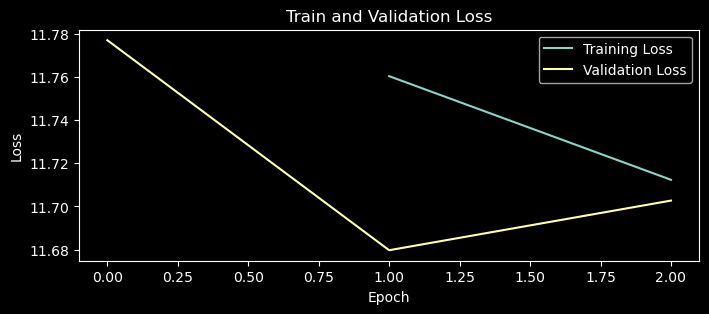

# Evaluating on Test Dateset: # Test loss: 11.71 

# Scout nb 1/2 Training End.

Scout nb 2/2 Training Start:


Using the latest cached version of the dataset since wikitext couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'wikitext-103-raw-v1' at C:\Users\user\.cache\huggingface\datasets\wikitext\wikitext-103-raw-v1\0.0.0\b08601e04326c79dfdd32d625aee71d232d685c3 (last modified on Tue Aug 20 08:45:20 2024).


# Llama-3 Reference Model loaded. Starting training model with 1 layer(s) unfrozen.
# Epoch: 0  (Before start training) 
# Evaluating on Validation Dateset: # Validation loss: 11.81 
# Epoch: 1 (Learning rate: 2e-05)  Training loss: 11.71 || Validation loss: 11.73
# Epoch: 2 (Learning rate: 1e-05)  Training loss: 11.72 || Validation loss: 11.72
{'train_results': [[11.707962017059327, 11.723131084442139]], 'validation_results': [[11.806169776916503, 11.728645610809327, 11.717191619873047]]}


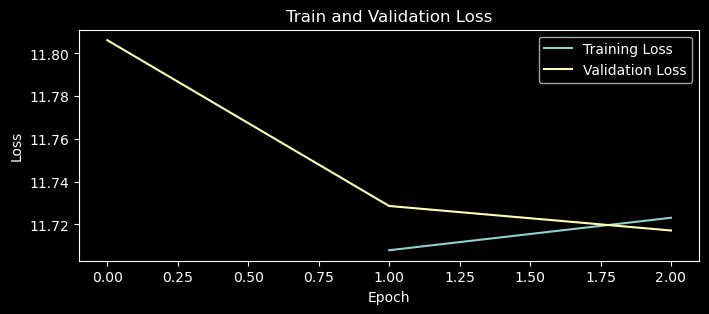

# Evaluating on Test Dateset: # Test loss: 11.73 

# Scout nb 2/2 Training End.

All Scouts Training End.

time: 1min 28s (started: 2024-08-21 17:00:52 +03:00)


In [43]:
# num_labels = 10 #already defined in whe crating reference BERT_Classification_model
nb_scouts =  2
epochs = 2 
patience  = 2 
batch_size = 4 
loss_function = nn.CrossEntropyLoss()  #combines the softmax activation function and the negative log-likelihood loss in a single operation
nb_of_layers_to_unfreeze = 1
dropout = 0.5
learning_rate = 2e-5

print("Start training :\n")
for i in range(nb_scouts): 
    print(f"=============================================================\nScout nb {i+1}/{nb_scouts} Training Start:")

    num_samples = 100
    # Subset the dataset
    train_subset = dataset['train'].select(range(num_samples))
    val_subset = dataset['validation'].select(range(num_samples))
    test_subset = dataset['test'] .select(range(num_samples))

    # Convert tokenized data to PyTorch Datasets
    train_dataset = CustomDataset(train_subset['text'], tokenizer=llama3_tokenizer, max_length=2048)
    val_dataset = CustomDataset(val_subset['text'], tokenizer=llama3_tokenizer, max_length=2048)
    test_dataset = CustomDataset(test_subset['text'], tokenizer=llama3_tokenizer, max_length=2048)

    # Create DataLoaders
    train_dataloader = DataLoader(train_dataset, batch_size=2, collate_fn=collate_fn, shuffle=True) 
    val_dataloader = DataLoader(val_dataset, batch_size=2, collate_fn=collate_fn, shuffle=True) 
    test_dataloader = DataLoader(test_dataset, batch_size=2, collate_fn=collate_fn, shuffle=True) 
    
    # Load reference model:
    llama3_model.load_state_dict(torch.load('C:/Users/user/Desktop/My_Files/Anaconda  Projects/data/Models/llama3_model_reference.pt'))

    print(f"# Llama-3 Reference Model loaded. Starting training model with {nb_of_layers_to_unfreeze} layer(s) unfrozen.") 

    
    # train model (not intersted in results: _)
    optimizer=AdamW(llama3_model.parameters(),lr=lr_train_classifier)
    print('================================================================')
    llama_3_losses = train_model(llama3_model,
                                 optimizer=AdamW(llama3_model.parameters(),lr=learning_rate),
                                 epochs=epochs,
                                 train_loader=train_dataloader,
                                 validation_loader=val_dataloader,
                                 patience=patience,
                                 train_verbose=True, 
                                 eval_verbose=True)
    print(llama_3_losses)
    plot_results(llama_3_losses)

    _ = evaluate_model(llama3_model,test_dataloader,dataset_category="Test") 

    print(f"\n# Scout nb {i+1}/{nb_scouts} Training End.\n=============================================================\n")
    llama3_scouts.add_scout(llama3_model) 
print("All Scouts Training End.\n=============================================================\n")



In [44]:
# Create the guidance matrix from the scouts:
llama3_raw_guidance_matrix = llama3_scouts.create_raw_guidance(DEVICE) 


time: 0 ns (started: 2024-08-21 17:07:27 +03:00)


In [45]:
gtl.save_guidance_matrix(llama3_raw_guidance_matrix, name='llama3_raw_guidance_matrix.pt') 

WindowsPath('c:/Users/user/Desktop/My_Files/Anaconda  Projects/DevTechPro/Notebooks/Guided Transfer Learning-DevTech/guided_transfer_learning_library/llama3_raw_guidance_matrix.pt')

time: 0 ns (started: 2024-08-21 17:07:29 +03:00)


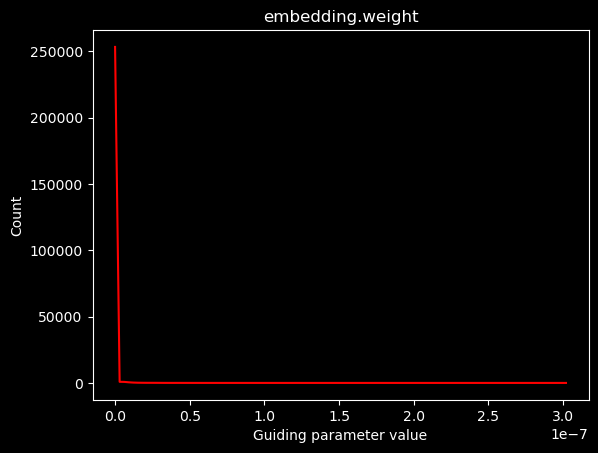

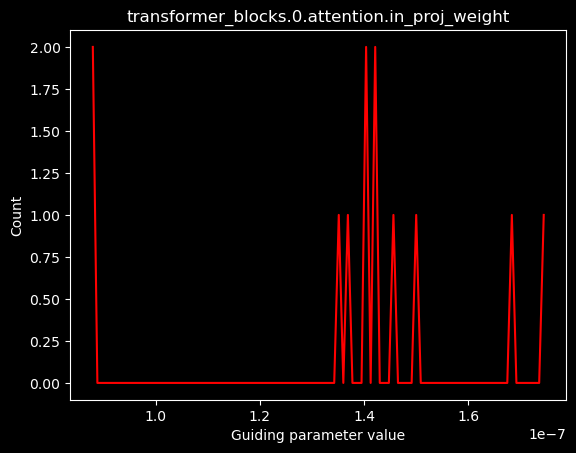

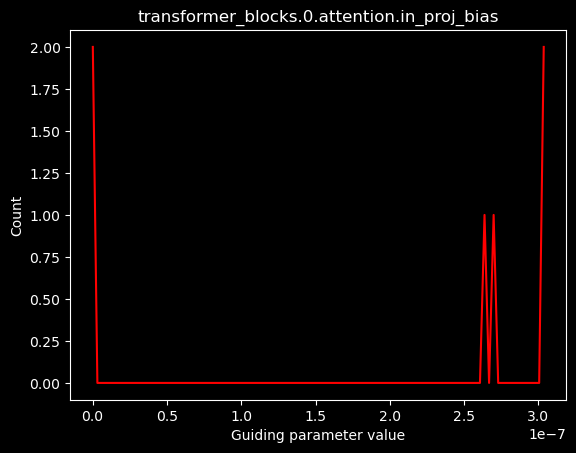

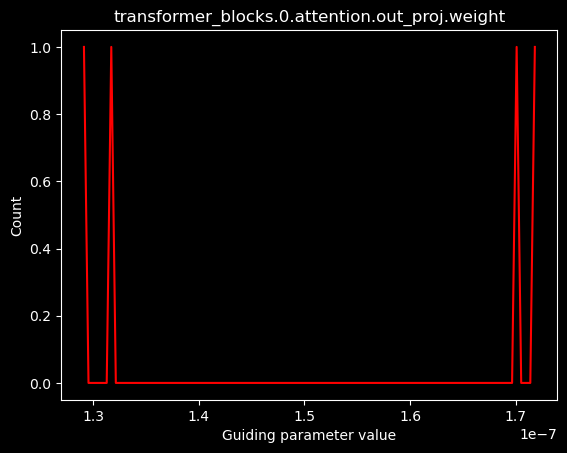

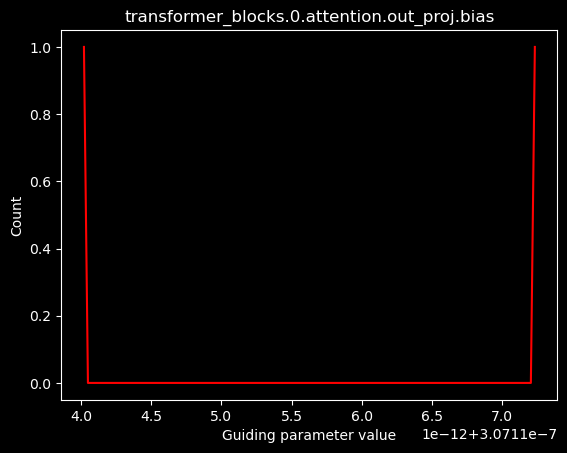

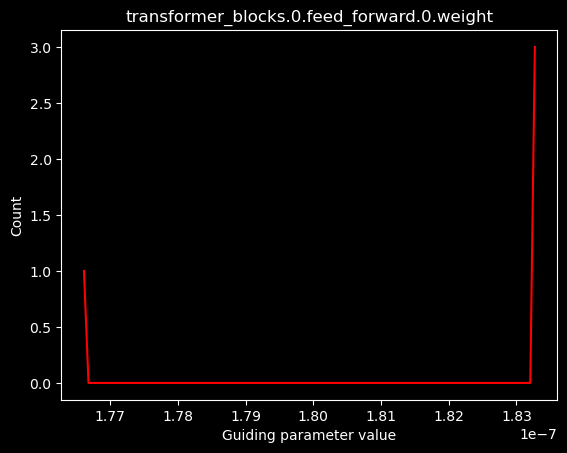

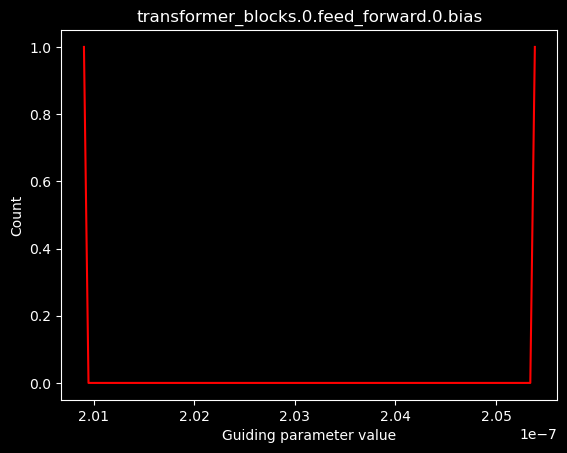

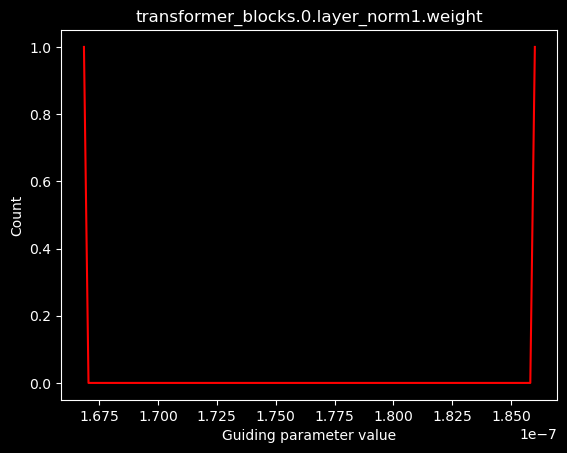

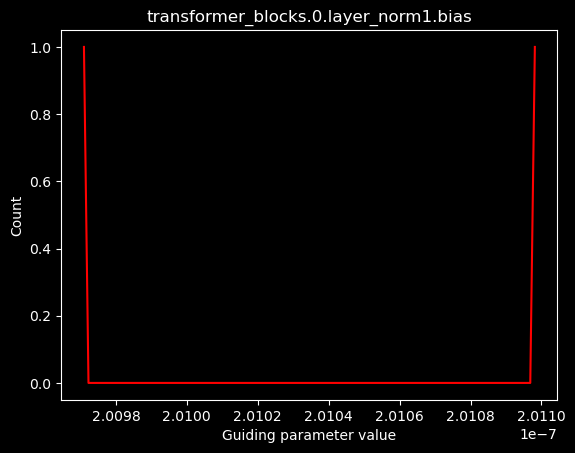

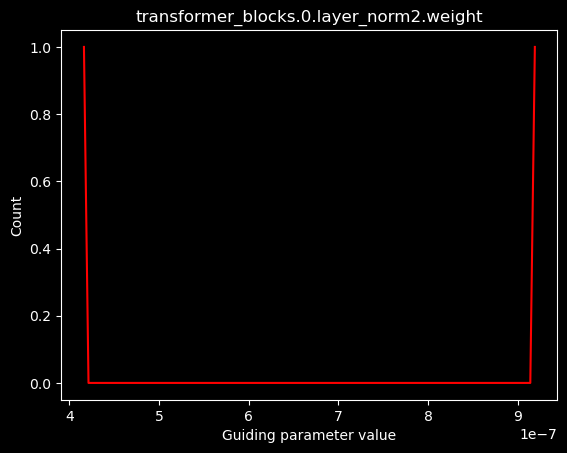

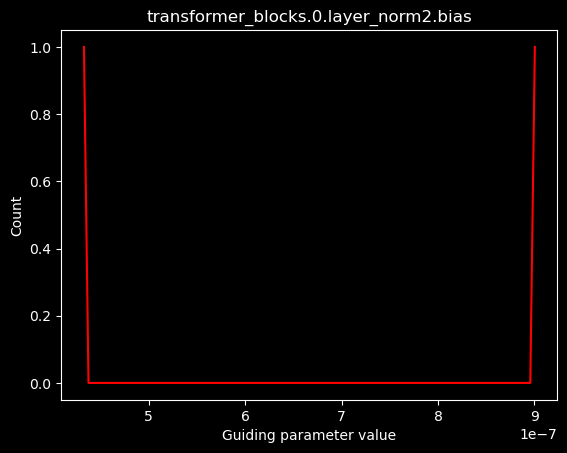

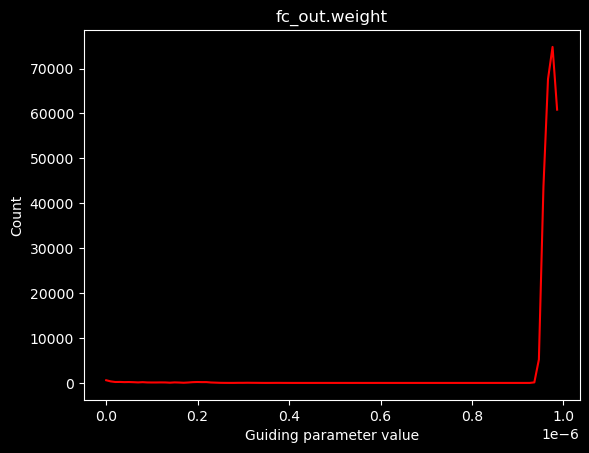

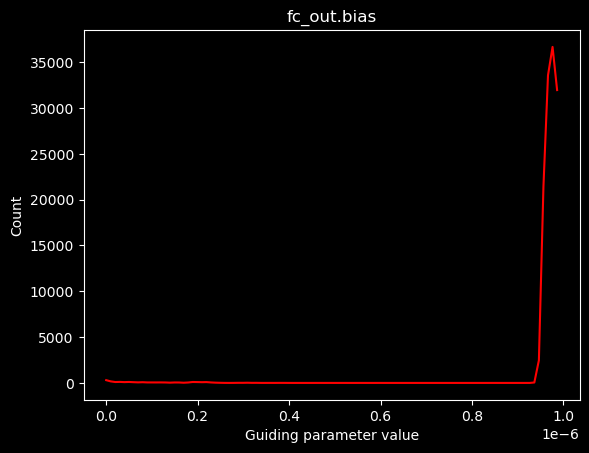

time: 1.11 s (started: 2024-08-21 17:07:30 +03:00)


In [46]:
gtl.plot_guidance_distribution(llama3_raw_guidance_matrix)

- Rescale Guidance Matrix

In [47]:
llama3_rescaled_guidance_matrix = llama3_raw_guidance_matrix.copy() 
def rescale_matrix_layer_by_layer(matrix):
    for layer in matrix:
        min_layer = torch.amin(matrix[layer])
        max_layer = torch.amax(matrix[layer])
        scale =  1/(max_layer - min_layer)
        if scale is not torch.inf:
            matrix[layer] = scale *  matrix[layer]
            
rescale_matrix_layer_by_layer(llama3_rescaled_guidance_matrix)
llama3_rescaled_guidance_matrix


{'embedding.weight': tensor([[5.6387e-04, 5.7086e-05],
         [3.5242e-05, 5.6387e-04],
         [1.2687e-03, 5.6387e-04],
         ...,
         [7.9294e-05, 2.2026e-06],
         [3.6535e-03, 8.8104e-06],
         [1.9823e-05, 1.2687e-03]], device='cuda:0'),
 'transformer_blocks.0.attention.in_proj_weight': tensor([[1.6303, 1.6725],
         [1.6337, 1.7169],
         [1.5741, 1.6102],
         [1.6146, 1.5465],
         [2.0058, 1.0061],
         [1.9293, 1.0058]], device='cuda:0'),
 'transformer_blocks.0.attention.in_proj_bias': tensor([8.8312e-01, 8.6517e-01, 4.2011e-04, 1.0290e-03, 9.9472e-01, 1.0004e+00],
        device='cuda:0'),
 'transformer_blocks.0.attention.out_proj.weight': tensor([[3.0612, 3.9527],
         [2.9937, 3.9937]], device='cuda:0'),
 'transformer_blocks.0.attention.out_proj.bias': tensor([94786.0859, 94787.0859], device='cuda:0'),
 'transformer_blocks.0.feed_forward.0.weight': tensor([[27.2417, 26.2459],
         [27.2383, 27.2459]], device='cuda:0'),
 'tran

time: 266 ms (started: 2024-08-21 17:07:35 +03:00)


##### Train With GTL: Few-Show Learn

In [ ]:
texts = [
    "In the serene countryside, the golden rays of the sun danced upon the lush green fields, painting a picturesque scene. The gentle breeze carried the sweet scent of blooming flowers, while birds chirped melodiously, creating a symphony of nature. The tranquil river flowed gracefully, reflecting the clear blue sky. A lone fisherman sat by the riverbank, casting his line with patience, his thoughts drifting like the clouds above. Children played nearby, their laughter echoing through the valley. It was a perfect day, where time seemed to stand still in nature's embrace.",
    
    "On a bustling city street, cars honked and people rushed by, each engrossed in their own world. The towering skyscrapers cast long shadows on the pavement below, where vendors sold their wares to passersby. A street musician played a soulful tune on his guitar, his music weaving through the noise of the city. A group of friends gathered at a nearby café, sharing stories and laughter over cups of steaming coffee. Despite the chaos, there was a sense of community, of lives intersecting in this vibrant urban jungle, each with a story to tell.",
    
    "In a quiet library, the scent of old books filled the air, and the only sounds were the soft rustling of pages and the occasional whisper. Sunlight streamed through tall windows, casting a warm glow on the rows of bookshelves that lined the walls. A young student sat at a wooden table, deeply engrossed in a thick novel, his eyes scanning the pages with curiosity. Nearby, an elderly man browsed the history section, his fingers tracing the spines of ancient tomes. It was a sanctuary of knowledge, where time slowed down and minds could wander freely.",
    
    "At the edge of a dense forest, a small cabin stood nestled among the trees, its wooden walls weathered by years of enduring the elements. Smoke curled lazily from the chimney, hinting at the warmth within. Inside, a fire crackled in the hearth, casting flickering shadows on the walls. A woman sat by the window, knitting a woolen scarf, her mind wandering to distant memories. Outside, a deer grazed near the treeline, its ears twitching at the slightest sound. The world seemed distant here, where nature's embrace offered solace and a connection to the earth.",
   
]


In [48]:
# Empty GPU cache
torch.cuda.empty_cache()

time: 47 ms (started: 2024-08-21 17:08:25 +03:00)


In [ ]:
dataset_name = "wikitext"
dataset = load_dataset(dataset_name, "wikitext-103-raw-v1")

# Llama-3 Reference Model loaded. Starting training model with 1 layer(s) unfrozen.
# Epoch: 0  (Before start training) 
# Evaluating on Validation Dateset: # Validation loss: 11.44 
# Epoch: 1 (Learning rate: 2e-05)  Training loss: 11.51 || Validation loss: 11.54
# Epoch: 2 (Learning rate: 1e-05)  Training loss: 11.47 || Validation loss: 11.53
{'train_results': [[11.50897071838379, 11.469415283203125]], 'validation_results': [[11.444371719360351, 11.5375394821167, 11.533320960998536]]}


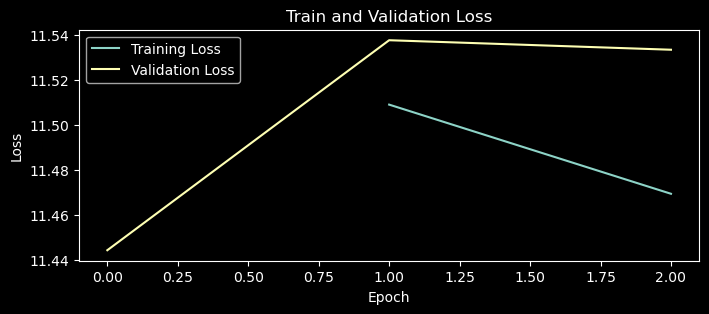

# Evaluating on Test Dateset: # Test loss: 11.46 
time: 37.5 s (started: 2024-08-21 17:14:58 +03:00)


In [50]:
##  Change dataset to give only one training example not from wikitext dataset  ## 

num_samples = 100
# Subset the dataset
train_subset = dataset['train'].select(range(num_samples))
val_subset = dataset['validation'].select(range(num_samples))
test_subset = dataset['test'] .select(range(num_samples))

# Convert tokenized data to PyTorch Datasets
train_dataset = CustomDataset(train_subset['text'], tokenizer=llama3_tokenizer, max_length=2048)
val_dataset = CustomDataset(val_subset['text'],tokenizer=llama3_tokenizer, max_length=2048)
test_dataset = CustomDataset(test_subset['text'], tokenizer=llama3_tokenizer, max_length=2048)

# Create DataLoaders
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, collate_fn=collate_fn, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size,collate_fn=collate_fn, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, collate_fn=collate_fn, shuffle=True)    

# Load reference model:
llama3_model.load_state_dict(torch.load('C:/Users/user/Desktop/My_Files/Anaconda  Projects/data/Models/llama3_model_reference.pt'))
print(f"# Llama-3 Reference Model loaded. Starting training model with {nb_of_layers_to_unfreeze} layer(s) unfrozen.") 

# train model (not intersted in results: _)
optimizer=AdamW(llama3_model.parameters(),lr=lr_train_classifier)
print('================================================================')

llama_3_losses = train_model(llama3_model,
                             optimizer=AdamW(llama3_model.parameters(),lr=learning_rate),
                             epochs=epochs,
                             train_loader=train_dataloader,
                             validation_loader=val_dataloader,
                             patience=patience,
                             train_verbose=True, 
                             eval_verbose=True,
                             with_GTL=True,
                             guidance_matrix=llama3_rescaled_guidance_matrix,
                             )
print(llama_3_losses) 
plot_results(llama_3_losses) 

_ = evaluate_model(llama3_model,test_dataloader,dataset_category="Test") 



##### Train Without GTL: Few-Shot Learn


In [51]:
# Empty GPU cache
torch.cuda.empty_cache()

time: 93 ms (started: 2024-08-21 17:15:47 +03:00)


In [52]:
dataset_name = "wikitext"
dataset = load_dataset(dataset_name, "wikitext-103-raw-v1")

time: 16.7 s (started: 2024-08-21 17:15:50 +03:00)


# Llama-3 Reference Model loaded. Starting training model with 1 layer(s) unfrozen.
# Epoch: 0  (Before start training) 
# Evaluating on Validation Dateset: # Validation loss: 11.49 
# Epoch: 1 (Learning rate: 2e-05)  Training loss: 11.45 || Validation loss: 11.44
# Epoch: 2 (Learning rate: 1e-05)  Training loss: 11.47 || Validation loss: 11.54
{'train_results': [[11.451268920898437, 11.466571960449219]], 'validation_results': [[11.488267707824708, 11.437790489196777, 11.535308074951171]]}


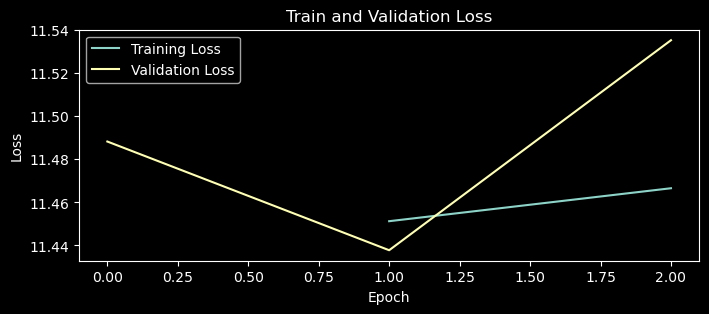

# Evaluating on Test Dateset: # Test loss: 11.45 
time: 33.7 s (started: 2024-08-21 17:16:46 +03:00)


In [53]:
##  Change dataset to give only one training example not from wikitext dataset  ## 


# num_labels = 10 #already defined in whe crating reference BERT_Classification_model
epochs = 2 
batch_size = 4 
learning_rate = 2e-5

num_samples = 100
# Subset the dataset
train_subset = dataset['train'].select(range(num_samples))
val_subset = dataset['validation'].select(range(num_samples))
test_subset = dataset['test'] .select(range(num_samples))

# Convert tokenized data to PyTorch Datasets
train_dataset = CustomDataset(train_subset['text'], tokenizer=llama3_tokenizer, max_length=2048)
val_dataset = CustomDataset(val_subset['text'],tokenizer=llama3_tokenizer, max_length=2048)
test_dataset = CustomDataset(test_subset['text'], tokenizer=llama3_tokenizer, max_length=2048)

# Create DataLoaders
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, collate_fn=collate_fn, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size,collate_fn=collate_fn, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, collate_fn=collate_fn, shuffle=True)    

# Load reference model:
llama3_model.load_state_dict(torch.load('C:/Users/user/Desktop/My_Files/Anaconda  Projects/data/Models/llama3_model_reference.pt'))

print(f"# Llama-3 Reference Model loaded. Starting training model with {nb_of_layers_to_unfreeze} layer(s) unfrozen.") 


# train model (not intersted in results: _)
optimizer=AdamW(llama3_model.parameters(),lr=lr_train_classifier)
print('================================================================')

llama_3_losses = train_model(llama3_model,
                             optimizer=AdamW(llama3_model.parameters(),lr=learning_rate),
                             epochs=epochs,train_loader=train_dataloader,
                             validation_loader=val_dataloader,
                             train_verbose=True, 
                             eval_verbose=True,
                             with_GTL=False,
                             )
print(llama_3_losses) 
plot_results(llama_3_losses) 

_ = evaluate_model(llama3_model,test_dataloader,dataset_category="Test") 